In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
import math
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler


# ==========================================================
# USER PARAMETERS
# ==========================================================

N_QUBITS = 10
MARKED_STATE = "1011010101"        # Must have length = N_QUBITS
SHOTS = 32768

USE_SIMULATOR = False  # Set to False to run on a real device

IBM_API_KEY = os.getenv("IBM_API_KEY")

# ==========================================================
# VALIDATION
# ==========================================================

if len(MARKED_STATE) != N_QUBITS:
    raise ValueError("Length of MARKED_STATE must equal N_QUBITS.")

# Reverse because Qiskit uses little-endian ordering
TARGET = MARKED_STATE[::-1]

# ==========================================================
# ORACLE
# ==========================================================

def oracle(qc, target):

    n = len(target)

    # Convert target state into |111...1>
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)

    # Phase flip
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Restore qubits
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)


# ==========================================================
# DIFFUSER
# ==========================================================

def diffuser(qc, n):

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    qc.x(range(n))
    qc.h(range(n))


# ==========================================================
# BUILD GROVER CIRCUIT
# ==========================================================

qc = QuantumCircuit(N_QUBITS)

# Uniform superposition
qc.h(range(N_QUBITS))

# Optimal iterations
iterations = max(
    1,
    int((math.pi / 4) * math.sqrt(2 ** N_QUBITS))
)

print(f"Using {iterations} Grover iterations")

for _ in range(iterations):

    oracle(qc, TARGET)

    diffuser(qc, N_QUBITS)

qc.measure_all()

# ==========================================================
# CONNECT TO IBM QUANTUM
# ==========================================================

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_API_KEY
)

if USE_SIMULATOR:

    backend = service.least_busy(
        simulator=True
    )

else:

    backend = service.least_busy(
        operational=True,
        simulator=False
    )

print("Backend:", backend.name)

# ==========================================================
# TRANSPILATION
# ==========================================================

transpiled = transpile(
    qc,
    backend=backend,
    optimization_level=3
)

# ==========================================================
# EXECUTION
# ==========================================================

sampler = Sampler(mode=backend)

job = sampler.run(
    [transpiled],
    shots=SHOTS
)

print("Job ID:", job.job_id())

result = job.result()

counts = result[0].data.meas.get_counts()

# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("\nMeasurement Counts\n")

sorted_counts = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)

for state, count in sorted_counts:

    marker = ""

    if state == MARKED_STATE:
        marker = " <--- TARGET"

    print(f"{state} : {count}{marker}")

## Without IBM hardware Only Single Qubit Marked State

Number of states : 16
Grover iterations: 3

Measurement Counts

1010 : 996  <--- TARGET
1000 : 5
1001 : 3
0000 : 3
1111 : 3
0110 : 3
0001 : 3
0010 : 2
1110 : 2
0011 : 1
0111 : 1
1100 : 1
1011 : 1


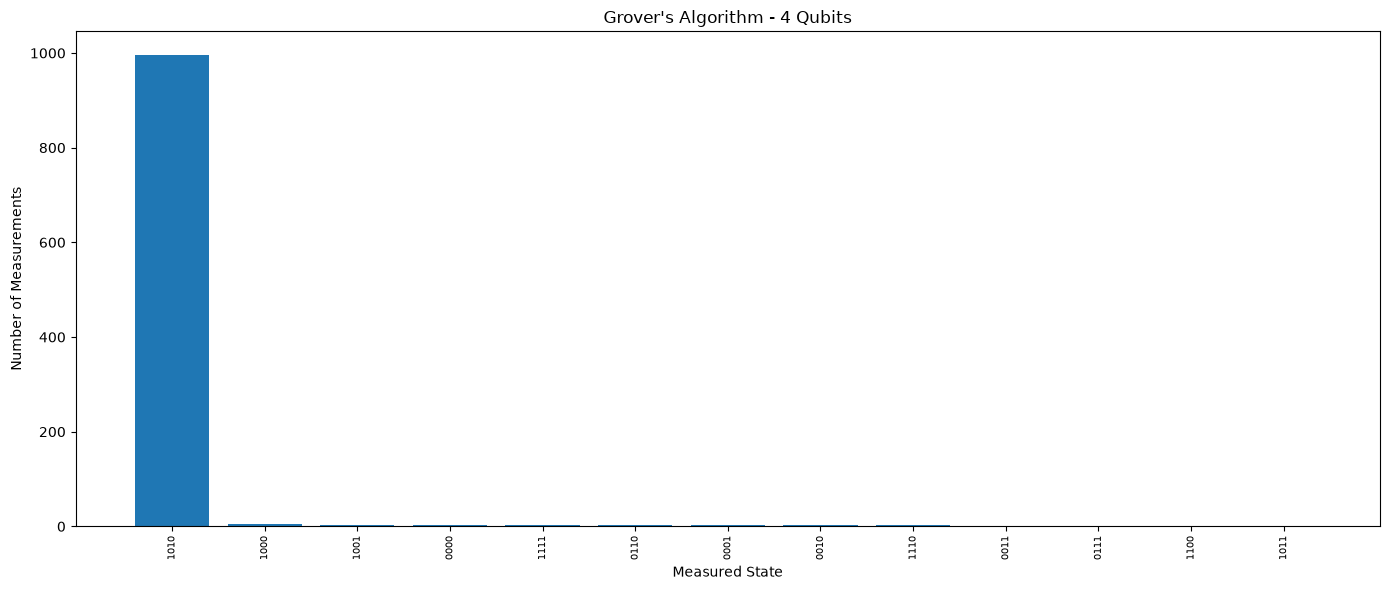

In [11]:
import math
import matplotlib.pyplot as plt
%matplotlib inline

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# ==========================================================
# USER PARAMETERS
# ==========================================================

N_QUBITS = 4
MARKED_STATE = "1010"
SHOTS = 1024


# ==========================================================
# VALIDATION
# ==========================================================

if len(MARKED_STATE) != N_QUBITS:
    raise ValueError("Length of MARKED_STATE must equal N_QUBITS.")

# Qiskit uses little-endian ordering internally
TARGET = MARKED_STATE[::-1]


# ==========================================================
# ORACLE
# ==========================================================

def oracle(qc, target):

    n = len(target)

    # Convert target |101...> into |111...>
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)

    # Phase flip
    qc.h(n - 1)
    qc.mcx(
        list(range(n - 1)),
        n - 1
    )
    qc.h(n - 1)

    # Restore original state
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)


# ==========================================================
# DIFFUSION OPERATOR
# ==========================================================

def diffuser(qc, n):

    # H^n
    qc.h(range(n))

    # X^n
    qc.x(range(n))

    # Multi-controlled Z
    qc.h(n - 1)

    qc.mcx(
        list(range(n - 1)),
        n - 1
    )

    qc.h(n - 1)

    # X^n
    qc.x(range(n))

    # H^n
    qc.h(range(n))


# ==========================================================
# BUILD GROVER CIRCUIT
# ==========================================================

qc = QuantumCircuit(N_QUBITS)

# ----------------------------------------------------------
# 1. Initial uniform superposition
# ----------------------------------------------------------

qc.h(range(N_QUBITS))


# ----------------------------------------------------------
# 2. Calculate Grover iterations
# ----------------------------------------------------------

N = 2 ** N_QUBITS

iterations = max(
    1,
    int((math.pi / 4) * math.sqrt(N))
)

print("Number of states :", N)
print("Grover iterations:", iterations)


# ----------------------------------------------------------
# 3. Grover iterations
# ----------------------------------------------------------

for i in range(iterations):

    oracle(qc, TARGET)

    diffuser(qc, N_QUBITS)


# ----------------------------------------------------------
# 4. Measurement
# ----------------------------------------------------------

qc.measure_all()


# ==========================================================
# LOCAL SIMULATOR
# ==========================================================

simulator = AerSimulator()

transpiled = transpile(
    qc,
    simulator,
    optimization_level=3
)


# ==========================================================
# RUN
# ==========================================================

result = simulator.run(
    transpiled,
    shots=SHOTS
).result()


counts = result.get_counts()


# ==========================================================
# SORT RESULTS
# ==========================================================

sorted_counts = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)


# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\nMeasurement Counts\n")

for state, count in sorted_counts:

    marker = ""

    if state == MARKED_STATE:
        marker = "  <--- TARGET"

    print(
        f"{state} : {count}{marker}"
    )


# ==========================================================
# BAR PLOT
# ==========================================================

states = [x[0] for x in sorted_counts]
values = [x[1] for x in sorted_counts]


plt.figure(figsize=(14, 6))

bars = plt.bar(
    states,
    values
)

# Highlight target
for bar, state in zip(bars, states):

    if state == MARKED_STATE:
        bar.set_linewidth(3)


plt.xlabel("Measured State")
plt.ylabel("Number of Measurements")
plt.title(
    f"Grover's Algorithm - {N_QUBITS} Qubits"
)

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.tight_layout()
plt.show()

In [5]:
"""
Grover's Algorithm - Local Simulation (Qiskit Aer)
====================================================
Runs entirely on your machine via AerSimulator.
No IBM Quantum account, API token, or real hardware is used or required.
"""

import math
import matplotlib
matplotlib.use("Agg")   # headless-safe backend; change to default if running in Jupyter
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# ==========================================================
# USER PARAMETERS
# ==========================================================

N_QUBITS = 4
MARKED_STATE = "1011"
SHOTS = 32768


# ==========================================================
# VALIDATION
# ==========================================================

if len(MARKED_STATE) != N_QUBITS:
    raise ValueError("Length of MARKED_STATE must equal N_QUBITS.")

# Qiskit uses little-endian ordering internally
TARGET = MARKED_STATE[::-1]


# ==========================================================
# ORACLE  (applies a phase flip to the marked state only)
# ==========================================================

def oracle(qc, target):
    n = len(target)

    # Map target |...> onto |11...1> so a single multi-controlled Z
    # (built here as H-MCX-H) flips the phase of exactly that state.
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)

    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Undo the mapping so the rest of the register is untouched
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)


# ==========================================================
# DIFFUSION OPERATOR (inversion about the mean)
# ==========================================================

def diffuser(qc, n):
    qc.h(range(n))
    qc.x(range(n))

    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    qc.x(range(n))
    qc.h(range(n))


# ==========================================================
# BUILD GROVER CIRCUIT
# ==========================================================

qc = QuantumCircuit(N_QUBITS)

# 1. Uniform superposition over all 2^N_QUBITS basis states
qc.h(range(N_QUBITS))

# 2. Optimal number of Grover iterations, derived from qubit count:
#       iterations = floor( (pi/4) * sqrt(N) ),  N = 2^N_QUBITS
N = 2 ** N_QUBITS
iterations = max(1, int((math.pi / 4) * math.sqrt(N)))

print("Number of states :", N)
print("Grover iterations:", iterations)

# 3. Apply the oracle + diffuser pair `iterations` times (NOT just once)
for i in range(iterations):
    oracle(qc, TARGET)
    diffuser(qc, N_QUBITS)

# 4. Measurement
qc.measure_all()


# ==========================================================
# LOCAL SIMULATOR  (no IBM hardware, no cloud queue)
# ==========================================================

simulator = AerSimulator()

transpiled = transpile(
    qc,
    simulator,
    optimization_level=3
)

result = simulator.run(transpiled, shots=SHOTS).result()
counts = result.get_counts()


# ==========================================================
# SORT + REPORT RESULTS
# ==========================================================

sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("\nMeasurement Counts\n")
for state, count in sorted_counts:
    marker = "  <--- TARGET" if state == MARKED_STATE else ""
    print(f"{state} : {count}{marker}")

target_count = counts.get(MARKED_STATE, 0)
print(f"\nTarget '{MARKED_STATE}' probability: {target_count/SHOTS:.4%} "
      f"({target_count}/{SHOTS} shots)")


# ==========================================================
# BAR PLOT
# ==========================================================

states = [x[0] for x in sorted_counts]
values = [x[1] for x in sorted_counts]

plt.figure(figsize=(14, 6))
bars = plt.bar(states, values)

for bar, state in zip(bars, states):
    if state == MARKED_STATE:
        bar.set_linewidth(3)
        bar.set_edgecolor("red")

plt.xlabel("Measured State")
plt.ylabel("Number of Measurements")
plt.title(f"Grover's Algorithm - {N_QUBITS} Qubits ({iterations} iterations, local Aer)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig("grover_result.png", dpi=150)
print("\nSaved plot to grover_result.png")

Number of states : 16
Grover iterations: 3

Measurement Counts

1011 : 31544  <--- TARGET
1101 : 94
1001 : 92
0110 : 92
0100 : 91
1010 : 86
0101 : 85
0000 : 85
1111 : 81
1110 : 80
0001 : 78
0011 : 76
0111 : 76
0010 : 71
1100 : 70
1000 : 67

Target '1011' probability: 96.2646% (31544/32768 shots)

Saved plot to grover_result.png
